# Superconductivity Critical Temperature Prediction with ElasticNet Regression

**Goal:** Solve all 16 project questions using `train.csv` and `unique_m.csv`, with an emphasis on regularization, multicollinearity, feature selection, model comparison, and practical R&D interpretation.

In [1]:
# Cell 1 — Imports and reproducibility settings.
from pathlib import Path
import sys, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_FIG = ROOT / "outputs" / "figures"
OUTPUT_REPORT = ROOT / "outputs" / "reports"
OUTPUT_MODEL = ROOT / "outputs" / "models"
for folder in [OUTPUT_FIG, OUTPUT_REPORT, OUTPUT_MODEL]:
    folder.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: d:\superconductivity_elasticnet_project


In [2]:
# Cell 2 — Load datasets using the exact Windows paths requested, with portable fallbacks.
WINDOWS_TRAIN = Path(r"C:\Users\Alok Agarwal\Downloads\superconductivty+data\train.csv")
WINDOWS_UNIQUE = Path(r"C:\Users\Alok Agarwal\Downloads\superconductivty+data\unique_m.csv")
LOCAL_TRAIN = ROOT / "data" / "raw" / "train.csv"
LOCAL_UNIQUE = ROOT / "data" / "raw" / "unique_m.csv"

def pick_path(primary, fallback):
    if primary.exists():
        return primary
    if fallback.exists():
        return fallback
    raise FileNotFoundError(f"Could not find {primary} or {fallback}")

train_path = pick_path(WINDOWS_TRAIN, LOCAL_TRAIN)
unique_path = pick_path(WINDOWS_UNIQUE, LOCAL_UNIQUE)
train_df = pd.read_csv(train_path)
unique_df = pd.read_csv(unique_path)
print("train.csv:", train_df.shape, "from", train_path)
print("unique_m.csv:", unique_df.shape, "from", unique_path)
display(train_df.head())

train.csv: (21263, 82) from C:\Users\Alok Agarwal\Downloads\superconductivty+data\train.csv
unique_m.csv: (21263, 88) from C:\Users\Alok Agarwal\Downloads\superconductivty+data\unique_m.csv


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [3]:
# Cell 3 — Verify target, duplicates, missing values, and numerical feature availability.
TARGET = "critical_temp"
assert TARGET in train_df.columns, "critical_temp target is missing from train.csv"
print("Missing values in train.csv:", int(train_df.isna().sum().sum()))
print("Duplicate rows in train.csv:", int(train_df.duplicated().sum()))
print("Predictor count:", train_df.shape[1] - 1)
print(train_df[TARGET].describe())

Missing values in train.csv: 0
Duplicate rows in train.csv: 66
Predictor count: 81
count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64


## Question 1
**What is the distribution of `critical_temp`, and does it contain skewness or extreme values?**

              value
count  21263.000000
mean      34.421219
std       34.254362
min        0.000210
25%        5.365000
50%       20.000000
75%       63.000000
max      185.000000
Skewness: 0.860
IQR outlier count: 1


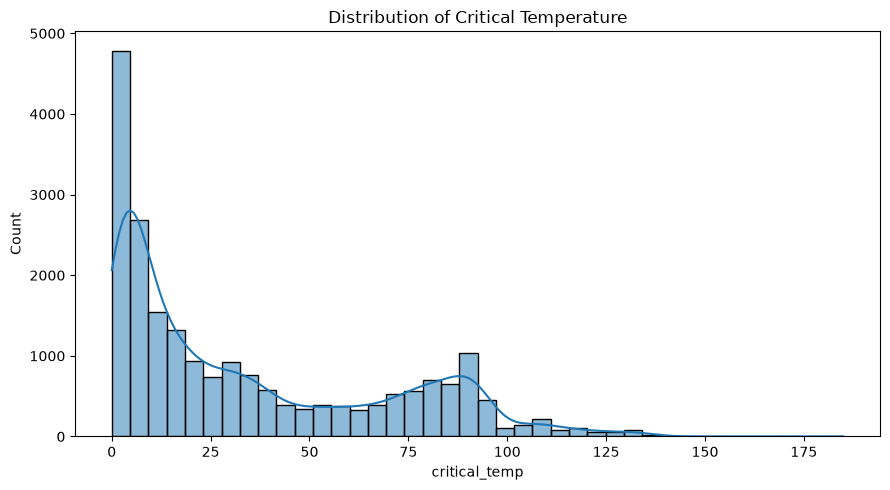

In [4]:
# Q1 — Summarize the target distribution and visualize central tendency and tail behavior.
target_stats = train_df[TARGET].describe().to_frame("value")
skewness = train_df[TARGET].skew()
q1, q3 = train_df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = train_df[(train_df[TARGET] < lower) | (train_df[TARGET] > upper)]
print(target_stats)
print(f"Skewness: {skewness:.3f}")
print(f"IQR outlier count: {len(outliers):,}")
plt.figure(figsize=(9,5))
sns.histplot(train_df[TARGET], kde=True, bins=40)
plt.title("Distribution of Critical Temperature")
plt.xlabel("critical_temp")
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "q1_target_distribution.png", dpi=160)
plt.show()

## Question 2
**Which features have the strongest positive and negative relationships with `critical_temp`?**

In [5]:
# Q2 — Compute Pearson correlations with the target and inspect both ends of the ranking.
corr_to_target = train_df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
print("Strongest negative correlations:\n", corr_to_target.head(10))
print("\nStrongest positive correlations:\n", corr_to_target.tail(10).sort_values(ascending=False))
q2_table = pd.concat([corr_to_target.head(10), corr_to_target.tail(10)]).to_frame("correlation")
q2_table.to_csv(OUTPUT_REPORT / "q2_target_correlations.csv")

Strongest negative correlations:
 wtd_mean_Valence       -0.632401
wtd_gmean_Valence      -0.615653
mean_Valence           -0.600085
gmean_Valence          -0.573068
gmean_Density          -0.541684
wtd_gmean_Density      -0.540046
wtd_range_Valence      -0.439901
wtd_mean_Density       -0.433940
wtd_gmean_FusionHeat   -0.432365
gmean_FusionHeat       -0.431795
Name: critical_temp, dtype: float64

Strongest positive correlations:
 wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
wtd_std_atomic_radius          0.599199
entropy_Valence                0.598591
Name: critical_temp, dtype: float64


## Question 3
**How much multicollinearity exists among the predictors, and which feature pairs are highly correlated?**

In [6]:
# Q3 — Find highly correlated predictor pairs without duplicating the symmetric matrix entries.
X_full = train_df.drop(columns=[TARGET])
corr_matrix = X_full.corr(numeric_only=True).abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0":"feature_1", "level_1":"feature_2", 0:"abs_correlation"})
    .query("abs_correlation >= 0.90")
    .sort_values("abs_correlation", ascending=False)
)
print(f"Feature pairs with |r| >= 0.90: {len(high_pairs)}")
display(high_pairs.head(25))
high_pairs.to_csv(OUTPUT_REPORT / "q3_high_correlation_pairs.csv", index=False)

Feature pairs with |r| >= 0.90: 74


,feature_1,feature_2,abs_correlation
1240,entropy_fie,entropy_atomic_radius,0.997739
5906,wtd_mean_Valence,wtd_gmean_Valence,0.994939
1290,entropy_fie,entropy_Valence,0.992726
986,wtd_mean_fie,wtd_gmean_fie,0.992331
5824,mean_Valence,gmean_Valence,0.989911
2100,entropy_atomic_radius,entropy_Valence,0.989546
5496,range_ThermalConductivity,std_ThermalConductivity,0.987867
4676,range_FusionHeat,std_FusionHeat,0.984574
1396,range_fie,std_fie,0.981628
1806,wtd_mean_atomic_radius,wtd_gmean_atomic_radius,0.980107


## Question 4
**Do weighted material-property features provide stronger predictive relationships than unweighted counterparts?**

In [7]:
# Q4 — Compare matched mean_* and wtd_mean_* features using absolute target correlation.
pairs = []
for col in train_df.columns:
    if col.startswith("mean_") and f"wtd_{col}" in train_df.columns:
        wcol = f"wtd_{col}"
        pairs.append({
            "property": col.replace("mean_", ""),
            "mean_abs_corr": abs(train_df[col].corr(train_df[TARGET])),
            "weighted_mean_abs_corr": abs(train_df[wcol].corr(train_df[TARGET]))
        })
weighted_compare = pd.DataFrame(pairs)
weighted_compare["weighted_stronger"] = weighted_compare["weighted_mean_abs_corr"] > weighted_compare["mean_abs_corr"]
display(weighted_compare.sort_values("weighted_mean_abs_corr", ascending=False))
print("Weighted version stronger for", int(weighted_compare["weighted_stronger"].sum()), "of", len(weighted_compare), "matched properties.")
weighted_compare.to_csv(OUTPUT_REPORT / "q4_weighted_vs_unweighted.csv", index=False)

,property,mean_abs_corr,weighted_mean_abs_corr,weighted_stronger
7,Valence,0.600085,0.632401,True
3,Density,0.368262,0.433940,True
1,fie,0.102268,0.398796,True
5,FusionHeat,0.385509,0.394117,True
6,ThermalConductivity,0.375813,0.379336,True
0,atomic_mass,0.113523,0.312272,True
2,atomic_radius,0.105273,0.297272,True
4,ElectronAffinity,0.193550,0.111516,False


Weighted version stronger for 7 of 8 matched properties.


## Question 5
**How does `number_of_elements` relate to superconducting critical temperature?**

,number_of_elements,count,mean,median,std
0,1,285,5.187997,4.000,6.300097
1,2,3280,5.763814,3.900,7.366376
2,3,3895,9.356729,5.800,10.672062
3,4,4496,36.550638,24.300,32.905730
4,5,5792,50.714220,47.900,32.889834
5,6,2666,59.628588,62.400,32.011802
6,7,774,66.833062,68.000,31.530556
7,8,61,86.521311,96.800,27.610320
8,9,14,73.228571,74.825,14.381408


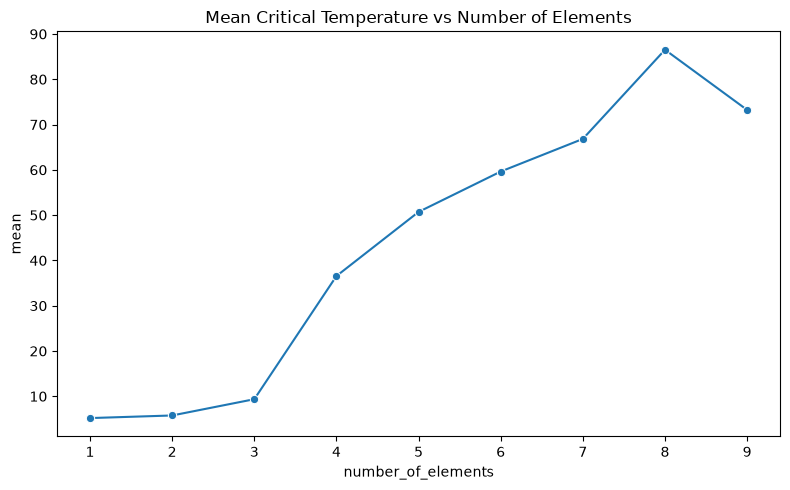

In [8]:
# Q5 — Aggregate critical temperature by number of elements and show sample size for context.
q5_summary = train_df.groupby("number_of_elements")[TARGET].agg(["count","mean","median","std"]).reset_index()
display(q5_summary)
plt.figure(figsize=(8,5))
sns.lineplot(data=q5_summary, x="number_of_elements", y="mean", marker="o")
plt.title("Mean Critical Temperature vs Number of Elements")
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "q5_elements_vs_temp.png", dpi=160)
plt.show()

## Question 6
**Which physical-property groups appear most important for predicting `critical_temp`?**

In [9]:
# Q6 — Group engineered features by property family and compare their strongest target correlations.
property_groups = ["atomic_mass", "fie", "atomic_radius", "Density", "ElectronAffinity", "FusionHeat", "ThermalConductivity", "Valence"]
rows = []
for group in property_groups:
    cols = [c for c in train_df.columns if group.lower() in c.lower() and c != TARGET]
    if cols:
        corrs = train_df[cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).abs()
        rows.append({"property_group": group, "feature_count": len(cols), "max_abs_corr": corrs.max(), "mean_abs_corr": corrs.mean(), "top_feature": corrs.idxmax()})
q6 = pd.DataFrame(rows).sort_values("max_abs_corr", ascending=False)
display(q6)
q6.to_csv(OUTPUT_REPORT / "q6_property_group_importance.csv", index=False)

,property_group,feature_count,max_abs_corr,mean_abs_corr,top_feature
6,ThermalConductivity,10,0.721271,0.424866,wtd_std_ThermalConductivity
2,atomic_radius,10,0.653759,0.427061,range_atomic_radius
7,Valence,10,0.632401,0.470101,wtd_mean_Valence
0,atomic_mass,10,0.626930,0.376372,wtd_entropy_atomic_mass
1,fie,10,0.600790,0.385118,range_fie
5,FusionHeat,10,0.563244,0.361151,wtd_entropy_FusionHeat
3,Density,10,0.541684,0.360946,gmean_Density
4,ElectronAffinity,10,0.437207,0.251015,entropy_ElectronAffinity


In [10]:
# Cell 10 — Create one reproducible train/test split and helper metrics for Q7–Q16.
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

def metrics_row(name, y_true, pred):
    mse = mean_squared_error(y_true, pred)
    return {"Model": name, "MAE": mean_absolute_error(y_true, pred), "MSE": mse, "RMSE": np.sqrt(mse), "R2": r2_score(y_true, pred)}

results = []

## Question 7
**How does a baseline Linear Regression model perform?**

In [11]:
# Q7 — Fit a standardized linear-regression baseline and evaluate on the untouched test set.
linear_pipe = Pipeline([("scale", StandardScaler()), ("model", LinearRegression())])
linear_pipe.fit(X_train, y_train)
linear_pred = linear_pipe.predict(X_test)
q7 = metrics_row("Linear Regression", y_test, linear_pred)
results.append(q7)
print(q7)

{'Model': 'Linear Regression', 'MAE': 13.210522050794125, 'MSE': 302.00751255011903, 'RMSE': np.float64(17.37836334497927), 'R2': 0.7376312737139082}


## Question 8
**Does Ridge Regression improve generalization when correlated predictors are present?**

In [12]:
# Q8 — Tune Ridge alpha with 5-fold CV, then evaluate the selected model on the test set.
ridge_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
    {"model__alpha": np.logspace(-3, 3, 13)},
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
ridge_pred = ridge_grid.predict(X_test)
q8 = metrics_row("Ridge", y_test, ridge_pred)
results.append(q8)
print("Best alpha:", ridge_grid.best_params_["model__alpha"])
print(q8)

Best alpha: 0.1
{'Model': 'Ridge', 'MAE': 13.210996205602797, 'MSE': 302.1473079094818, 'RMSE': np.float64(17.382384989105546), 'R2': 0.7375098266344399}


## Question 9
**Which features does Lasso shrink to zero?**

In [13]:
# Q9 — Tune Lasso, evaluate it, and inspect zero vs non-zero coefficients after scaling.
lasso_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=30000))]),
    {"model__alpha": np.logspace(-4, 0, 9)},
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)
lasso_grid.fit(X_train, y_train)
lasso_pred = lasso_grid.predict(X_test)
q9 = metrics_row("Lasso", y_test, lasso_pred)
results.append(q9)
coef = lasso_grid.best_estimator_.named_steps["model"].coef_
lasso_coef = pd.DataFrame({"feature": X.columns, "coefficient": coef})
print("Best alpha:", lasso_grid.best_params_["model__alpha"])
print("Zero coefficients:", int((np.isclose(coef, 0)).sum()))
print("Non-zero coefficients:", int((~np.isclose(coef, 0)).sum()))
display(lasso_coef.reindex(lasso_coef.coefficient.abs().sort_values(ascending=False).index).head(20))
lasso_coef.to_csv(OUTPUT_REPORT / "q9_lasso_coefficients.csv", index=False)

Best alpha: 0.0001
Zero coefficients: 0
Non-zero coefficients: 81


,feature,coefficient
24,wtd_gmean_atomic_radius,-86.234224
22,wtd_mean_atomic_radius,80.823204
15,entropy_fie,-36.291366
2,wtd_mean_atomic_mass,-31.585658
74,wtd_gmean_Valence,-29.338459
52,wtd_mean_FusionHeat,-28.540286
49,std_ElectronAffinity,28.294207
75,entropy_Valence,28.233214
76,wtd_entropy_Valence,-26.387249
1,mean_atomic_mass,25.558550


## Question 10
**Does ElasticNet outperform Linear, Ridge, and Lasso?**

In [ ]:
# Q10 — Search a practical ElasticNet parameter grid and compare its test metrics with prior models.
elastic_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("model", ElasticNet(max_iter=30000, random_state=RANDOM_STATE))]),
    {"model__alpha": np.logspace(-4, 0, 9), "model__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9]},
    scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)
elastic_grid.fit(X_train, y_train)
elastic_pred = elastic_grid.predict(X_test)
q10 = metrics_row("ElasticNet", y_test, elastic_pred)
results.append(q10)
comparison = pd.DataFrame(results).sort_values("RMSE")
display(comparison)
comparison.to_csv(OUTPUT_REPORT / "q10_model_comparison.csv", index=False)

## Question 11
**Which `alpha` and `l1_ratio` combination gives the best ElasticNet model?**

In [ ]:
# Q11 — Report the selected ElasticNet hyperparameters and inspect the best CV RMSE.
best_alpha = elastic_grid.best_params_["model__alpha"]
best_l1_ratio = elastic_grid.best_params_["model__l1_ratio"]
best_cv_rmse = -elastic_grid.best_score_
print(f"Best alpha: {best_alpha}")
print(f"Best l1_ratio: {best_l1_ratio}")
print(f"Best 5-fold CV RMSE: {best_cv_rmse:.4f}")

## Question 12
**How stable is the best ElasticNet under 5-fold cross-validation?**

In [ ]:
# Q12 — Re-evaluate the selected ElasticNet pipeline with shuffled 5-fold CV and report mean ± std.
best_elastic = elastic_grid.best_estimator_
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    best_elastic, X_train, y_train, cv=cv,
    scoring={"rmse":"neg_root_mean_squared_error", "r2":"r2"}, n_jobs=-1
)
rmse_scores = -cv_scores["test_rmse"]
r2_scores = cv_scores["test_r2"]
print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"R²:   {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

## Question 13
**Which variables retain the largest positive and negative ElasticNet coefficients?**

In [ ]:
# Q13 — Extract standardized ElasticNet coefficients for interpretable direction and relative magnitude.
elastic_coef = best_elastic.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": X.columns, "coefficient": elastic_coef})
positive = coef_df.sort_values("coefficient", ascending=False).head(15)
negative = coef_df.sort_values("coefficient").head(15)
print("Largest positive coefficients:")
display(positive)
print("Largest negative coefficients:")
display(negative)
coef_df.to_csv(OUTPUT_REPORT / "q13_elasticnet_coefficients.csv", index=False)

## Question 14
**How well does the final ElasticNet model perform on the untouched test set, and what do residuals show?**

In [ ]:
# Q14 — Evaluate final test metrics and visualize actual-vs-predicted values plus residual behavior.
final_metrics = metrics_row("Final ElasticNet", y_test, elastic_pred)
print(final_metrics)
residuals = y_test.to_numpy() - elastic_pred

plt.figure(figsize=(6,6))
plt.scatter(y_test, elastic_pred, alpha=0.35)
lims = [min(y_test.min(), elastic_pred.min()), max(y_test.max(), elastic_pred.max())]
plt.plot(lims, lims, "--")
plt.xlabel("Actual critical_temp")
plt.ylabel("Predicted critical_temp")
plt.title("Actual vs Predicted — ElasticNet")
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "q14_actual_vs_predicted.png", dpi=160)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=40)
plt.title("ElasticNet Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.savefig(OUTPUT_FIG / "q14_residuals.png", dpi=160)
plt.show()

## Question 15
**Can elemental-composition information from `unique_m.csv` improve prediction beyond `train.csv` alone?**

In [ ]:
# Q15 — Align both files by row order, add elemental composition columns, and compare ElasticNet CV RMSE.
# The source dataset supplies the two files with matching row order and target values; we verify that before combining.
assert len(train_df) == len(unique_df), "Files have different row counts and cannot be row-aligned safely."
assert np.allclose(train_df[TARGET].to_numpy(), unique_df[TARGET].to_numpy()), "Target rows are not aligned between files."
composition_cols = [c for c in unique_df.columns if c not in [TARGET, "material"]]
combined_X = pd.concat([train_df.drop(columns=[TARGET]).reset_index(drop=True), unique_df[composition_cols].reset_index(drop=True)], axis=1)
combined_y = train_df[TARGET].reset_index(drop=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(combined_X, combined_y, test_size=0.20, random_state=RANDOM_STATE)
combined_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=30000, random_state=RANDOM_STATE))
])
combined_model.fit(Xc_train, yc_train)
combined_pred = combined_model.predict(Xc_test)
combined_metrics = metrics_row("ElasticNet + elemental composition", yc_test, combined_pred)
q15_compare = pd.DataFrame([final_metrics, combined_metrics]).sort_values("RMSE")
display(q15_compare)
q15_compare.to_csv(OUTPUT_REPORT / "q15_composition_comparison.csv", index=False)

## Question 16 — Deep Business / Industry Analysis
**If this model were used by a superconducting-materials R&D team, which material properties should researchers prioritize, and how could the model reduce experimental cost, testing time, and low-potential laboratory trials?**

In [ ]:
# Q16 — Translate the model into an R&D screening workflow using coefficient magnitude and prediction bands.
# This is decision support, not a replacement for laboratory validation or causal scientific evidence.
coef_priority = coef_df.assign(abs_coefficient=coef_df["coefficient"].abs()).sort_values("abs_coefficient", ascending=False).head(20)
print("Top model-priority engineered features for follow-up investigation:")
display(coef_priority[["feature", "coefficient", "abs_coefficient"]])

# Create an example triage table from the test set: higher predicted critical_temp candidates are screened first.
rd_triage = X_test.copy().reset_index(drop=True)
rd_triage["predicted_critical_temp"] = elastic_pred
rd_triage["actual_critical_temp_for_validation"] = y_test.reset_index(drop=True)
rd_triage["priority_rank"] = rd_triage["predicted_critical_temp"].rank(method="dense", ascending=False).astype(int)
rd_triage = rd_triage.sort_values("priority_rank")
display(rd_triage[["priority_rank", "predicted_critical_temp", "actual_critical_temp_for_validation"]].head(20))
rd_triage.to_csv(OUTPUT_REPORT / "q16_rd_screening_priority.csv", index=False)

print("\nBusiness/R&D interpretation:")
print("1. Use the model as a pre-screening layer before expensive laboratory experiments.")
print("2. Prioritize candidates with high predicted critical temperature for earlier validation.")
print("3. Use large-magnitude ElasticNet coefficients as hypothesis-generating signals, not causal proof.")
print("4. Track false negatives carefully so promising materials are not permanently discarded.")
print("5. Re-train the model as new laboratory results become available.")

## Final Model Summary

In [ ]:
# Final cell — Save the selected model and a compact summary for reproducibility.
joblib.dump(best_elastic, OUTPUT_MODEL / "best_elasticnet_model.joblib")
summary = {
    "rows": int(train_df.shape[0]),
    "predictors": int(train_df.shape[1] - 1),
    "best_alpha": float(best_alpha),
    "best_l1_ratio": float(best_l1_ratio),
    "test_metrics": {k: float(v) for k, v in final_metrics.items() if k != "Model"},
    "cv_rmse_mean": float(rmse_scores.mean()),
    "cv_rmse_std": float(rmse_scores.std()),
    "cv_r2_mean": float(r2_scores.mean()),
    "cv_r2_std": float(r2_scores.std()),
}
with open(OUTPUT_REPORT / "final_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print("Saved model to:", OUTPUT_MODEL / "best_elasticnet_model.joblib")